In [1]:
import scipy as sp
from pylab import *
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.pylab as pylab
import pandas as pd
import seaborn as sns
import random
import openpyxl


from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

sns.set_style("ticks")

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}



session_name="results/test"


In [2]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution():
    k=0.8
    return np.random.exponential(k)


u=0.8
o=0
f_interaction=lambda : uniform_distribution(u,o)
num_C=36
num_S=24
N=num_C*num_S

I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)



def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)


Folder 'results/test' already exists.


In [3]:
y=run_lotka_volterra(y, np.linspace(0, 1000, 5000), CommunitiesLibrary[i,:], I, g, k)
np.matmul(I,y)

NameError: name 'y' is not defined

In [ ]:

DominanceMatrix_BC=np.zeros([num_C,num_C])
DominanceMatrix_J=np.zeros([num_C,num_C])
DominanceMatrix_JS=np.zeros([num_C,num_C])

threshold=0.0001
y_list=np.zeros([num_C,N])
for i in range(num_C):
    y=np.random.rand(N)*0.1
    y=run_lotka_volterra(y, np.linspace(0, 1500, 7500), CommunitiesLibrary[i,:], I, g, k)
    y[y<threshold]=0
    y_list[i,:]=y

for i in range(num_C):
    for j in range(i,num_C):#range(i,num_C):
        y1= y_list[i,:]
        y2= y_list[j,:]

        
        y3=run_lotka_volterra((y1+y2)/2, np.linspace(0, 1500, 7500), (y1+y2)>threshold, I, g, k)
        y3[y3<threshold]=0

        DominanceMatrix_BC[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))
        DominanceMatrix_BC[j,i]=1-DominanceMatrix_BC[i,j]
        DominanceMatrix_J[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJ(x,y,z)))
        DominanceMatrix_J[j,i]=1-DominanceMatrix_J[i,j]
        DominanceMatrix_JS[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJS(x,y,z)))
        DominanceMatrix_JS[j,i]=1-DominanceMatrix_JS[i,j]


        

In [ ]:
A=I.flatten().tolist()
A.remove(1.0)
plt.hist(A,bins=10, alpha=0.5, color='green')




In [13]:
DominanceMatrix_BC

array([[           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan],
       [           nan, 5.00000000e-01, 7.78438000e-03, 7.78485478e-01,
                   nan, 6.58858849e-02, 9.99293526e-01, 3.46239284e-02],
       [           nan, 9.92215620e-01, 5.00000000e-01, 8.98888290e-01,
        6.66346248e-01, 8.66859059e-01, 9.86107710e-01, 1.35477981e-01],
       [           nan, 2.21514522e-01, 1.01111710e-01, 5.00000000e-01,
        6.28539479e-01, 5.33995660e-01, 8.40937298e-01, 7.11914925e-02],
       [           nan,            nan, 3.33653752e-01, 3.71460521e-01,
        5.00000000e-01, 9.99999999e-01, 2.09130101e-01, 2.33752297e-01],
       [           nan, 9.34114115e-01, 1.33140941e-01, 4.66004340e-01,
        9.62870339e-10, 5.00000000e-01, 9.99625328e-01, 2.53699833e-01],
       [           nan, 7.06473947e-04, 1.38922903e-02, 1.59062702e-01,
        7.90869899e-01, 3.74672168e-04, 5.00000000e-01, 8.

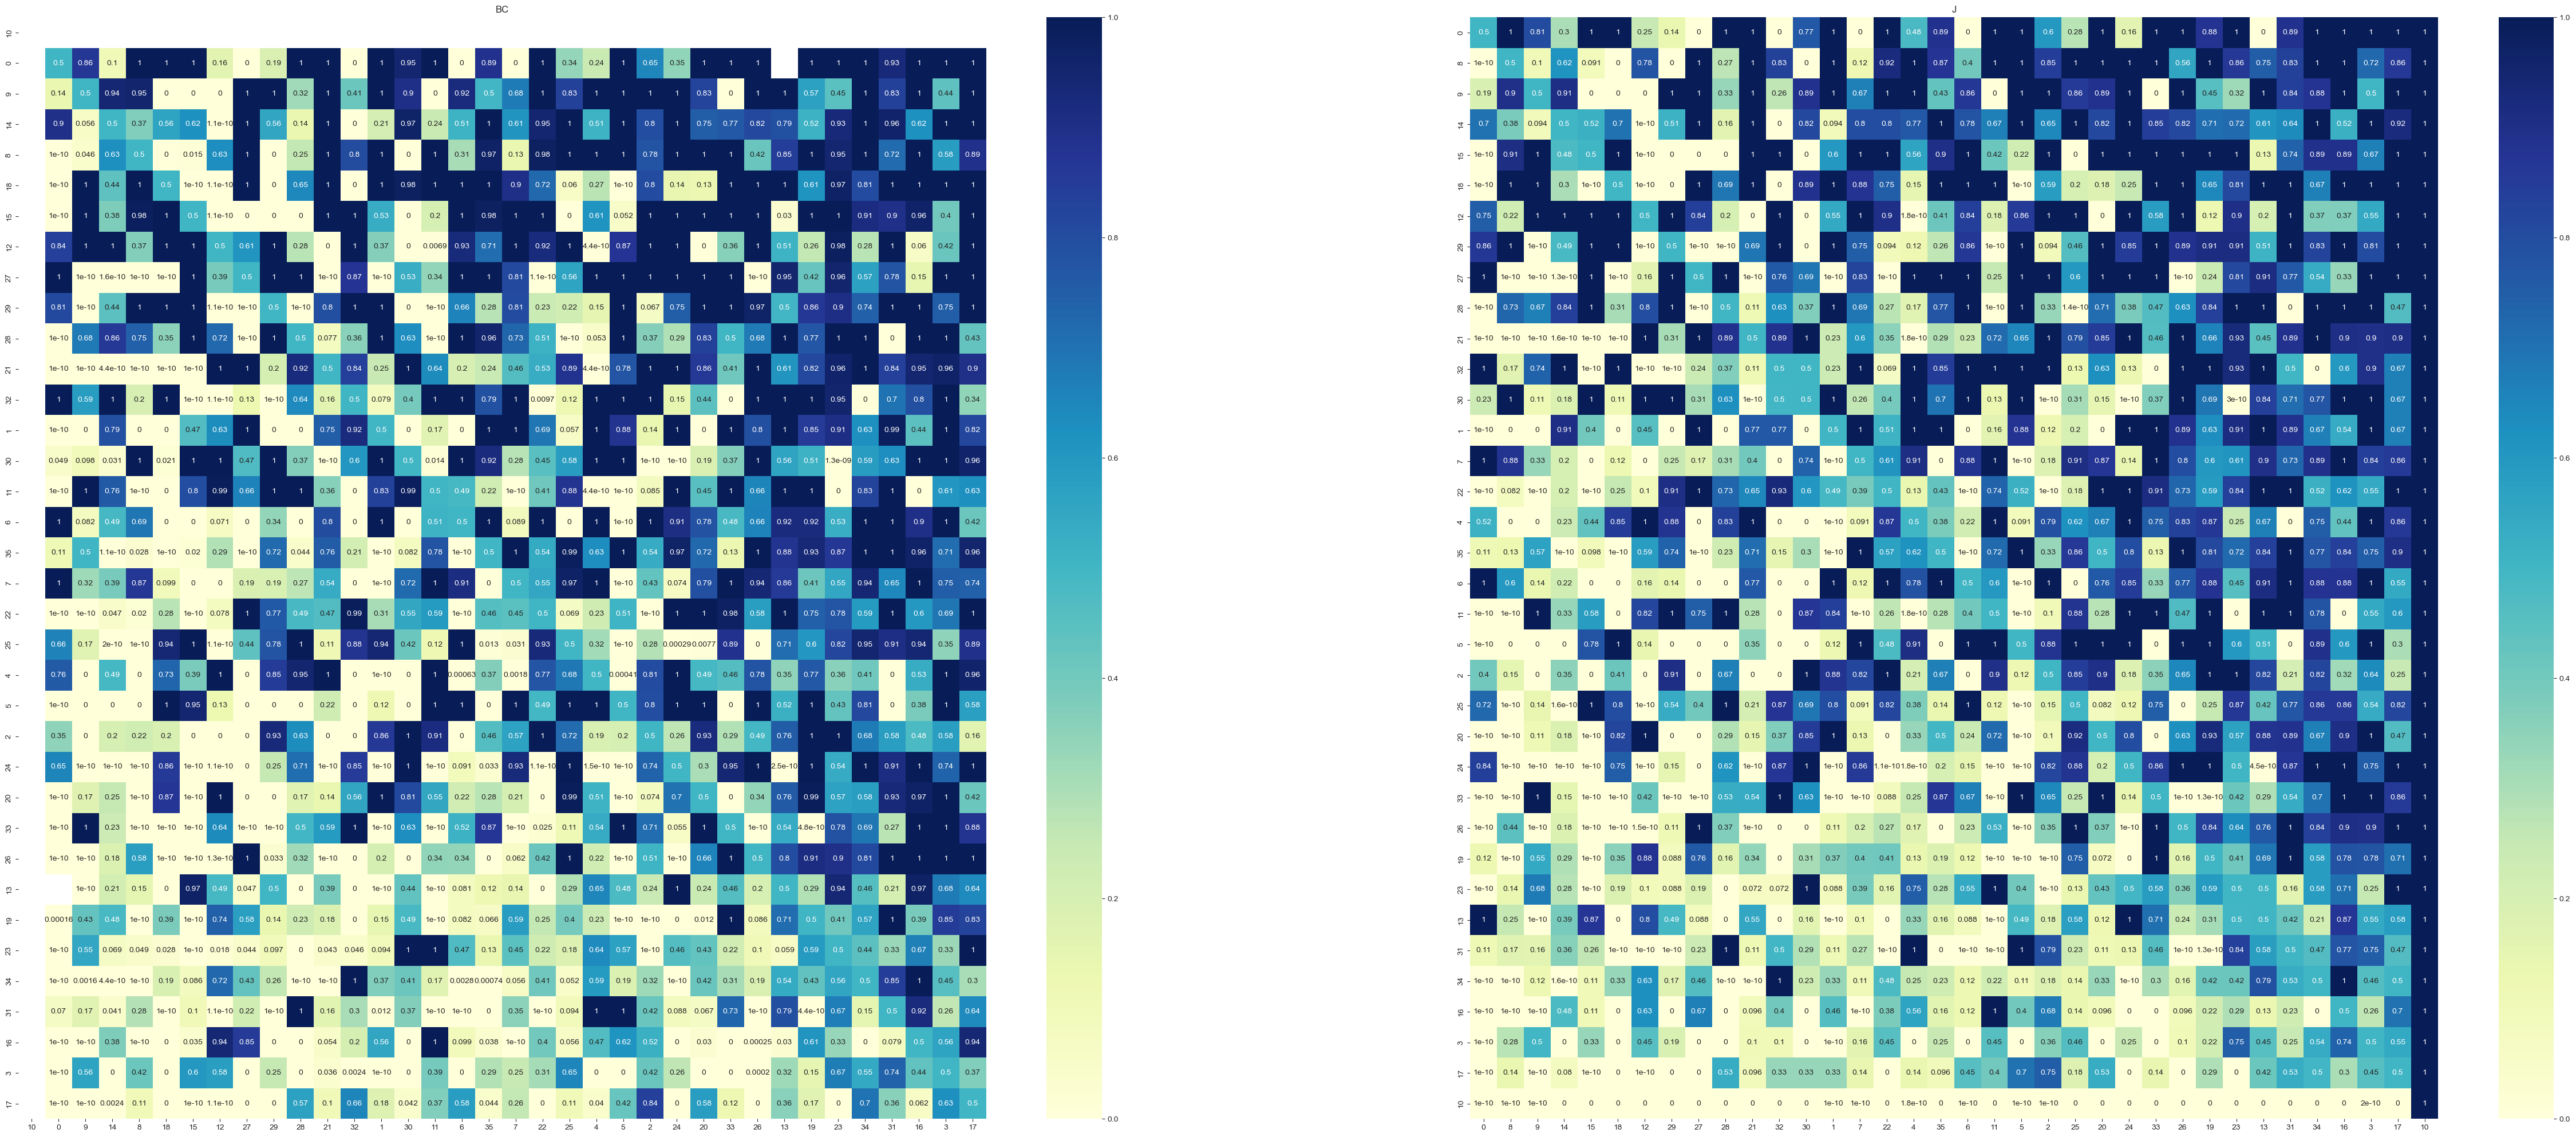

In [202]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(60, 25), dpi=100, facecolor='w', edgecolor='k')

rep=1
    
matrix=DominanceMatrix_BC
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)

# Create list of competitive scores

competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
df1=df_sorted

# Create heatmap with clustered rows and columns
sns.heatmap(df1, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[0])
axs[0].set_title("BC")

matrix=DominanceMatrix_J
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)

# Create list of competitive scores

competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
df1=df_sorted

# Create heatmap with clustered rows and columns
sns.heatmap(df1, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[1])
axs[1].set_title("J")

fig.savefig("Figures/Hiearchy_Analysis_largeNumber"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')

plt.show()




In [203]:
def internalI_mean_before_assembly(I, y_list, s_idx, threshold):
    
    s_idx=np.where(s_idx)[0].tolist()
    I_mean_1=I[s_idx,:]
    I_mean_1=I_mean_1[:,s_idx]
    I_mean_1=I_mean_1.flatten().tolist()
    #I_mean_1.remove(1.0)
    return mean(I_mean_1)

def internalI_mean_after_assembly(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_mean_2=I[s_idx,:]
    I_mean_2=I_mean_2[:,s_idx]
    I_mean_2=I_mean_2.flatten().tolist()
    if 1.0 in I_mean_2:
        I_mean_2.remove(1.0)
    return mean(I_mean_2)

def internalI_symmetry(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    I_c=I_c.flatten().tolist()
    if 1.0 in I_c:
        I_c.remove(1.0)
    I_r=I_c[::-1]
    mean_I=mean(I_r)
    std_c = np.std(I_r)
    std_r = np.std(I_c)    
    cov = np.sum((I_r - mean_I) * (I_c - mean_I)) / (len(I_r) - 1)
    corr = cov / (std_c * std_r)
    return corr

def internalI_symmetry_weighted(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    I_c=np.multiply(I_c, y_list[s_idx])
    np.fill_diagonal(I_c,np.mean(I_c))
    I_c=I_c.flatten().tolist()
    I_r=I_c[::-1]
    mean_I=mean(I_r)
    std_c = np.std(I_r)
    std_r = np.std(I_c)    
    cov = np.sum((I_r - mean_I) * (I_c - mean_I)) / (len(I_r) - 1)
    corr = cov / (std_c * std_r)
    return corr

def internalI_det(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    return np.linalg.det(I_c)

def I_assay(I, y_list, s_idx, threshold):
    
    return internalI_mean_before_assembly(I, y_list, s_idx, threshold), \
    internalI_mean_after_assembly(I, y_list, s_idx, threshold), \
    internalI_symmetry(I,y_list,s_idx,threshold), \
    internalI_symmetry_weighted(I, y_list, s_idx, threshold), \
    internalI_det(I, y_list, s_idx, threshold)

for i in sorted_idx:
    print (competitive_scores[i], i, sum(y_list[i,:]), Diversity2(y_list[i,:]/sum(y_list[i,:]), 0.0001) ,I_assay(I,y_list[i,:],CommunitiesLibrary[i,:],0.0001))
    

0.692711605676989 0 1.9959791014912902 1.3034337641402671 (0.826723801004452, 0.46566849342889566, -0.17396725684056652, -0.3897804434783502, 0.7286861864437032)
0.6925078781014178 8 1.8766268701326818 1.7972468784253757 (0.7868558488812136, 0.585270990739532, 0.0258949574328107, 0.00835327979753791, 1.9917301998403816)
0.6858156984998814 9 2.1092729208956413 1.3630826148423265 (0.8067100983180597, 0.4356923462337742, -0.13642317232554246, 0.14904593930267332, 0.5525395910669406)
0.6819713914086957 14 1.6488775318121047 1.8617437492937798 (0.8192536248375137, 0.6395043088153318, -0.1632830296511236, 0.5434334162495912, 0.4624898716668379)
0.6642113452611824 15 1.8486175553089912 1.379986496392424 (0.8152058820384842, 0.6411166412433797, -0.07267885302027226, -0.23333392661953967, 0.6481281106601854)
0.6529569871081168 18 1.9956606966563895 1.3165543710827303 (0.7883289542830912, 0.4579637110179025, -0.3853787855253064, -0.21733866435170396, 0.6302016858621531)
0.6486719552820386 12 3.2

/var/folders/jx/rq_jr02135l_jt9wtyd2x47c0000gn/T/ipykernel_21848/66865487.py:64: RuntimeWarning: invalid value encountered in divide
  print (competitive_scores[i], i, sum(y_list[i,:]), Diversity2(y_list[i,:]/sum(y_list[i,:]), 0.0001) ,I_assay(I,y_list[i,:],CommunitiesLibrary[i,:],0.0001))
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encounte

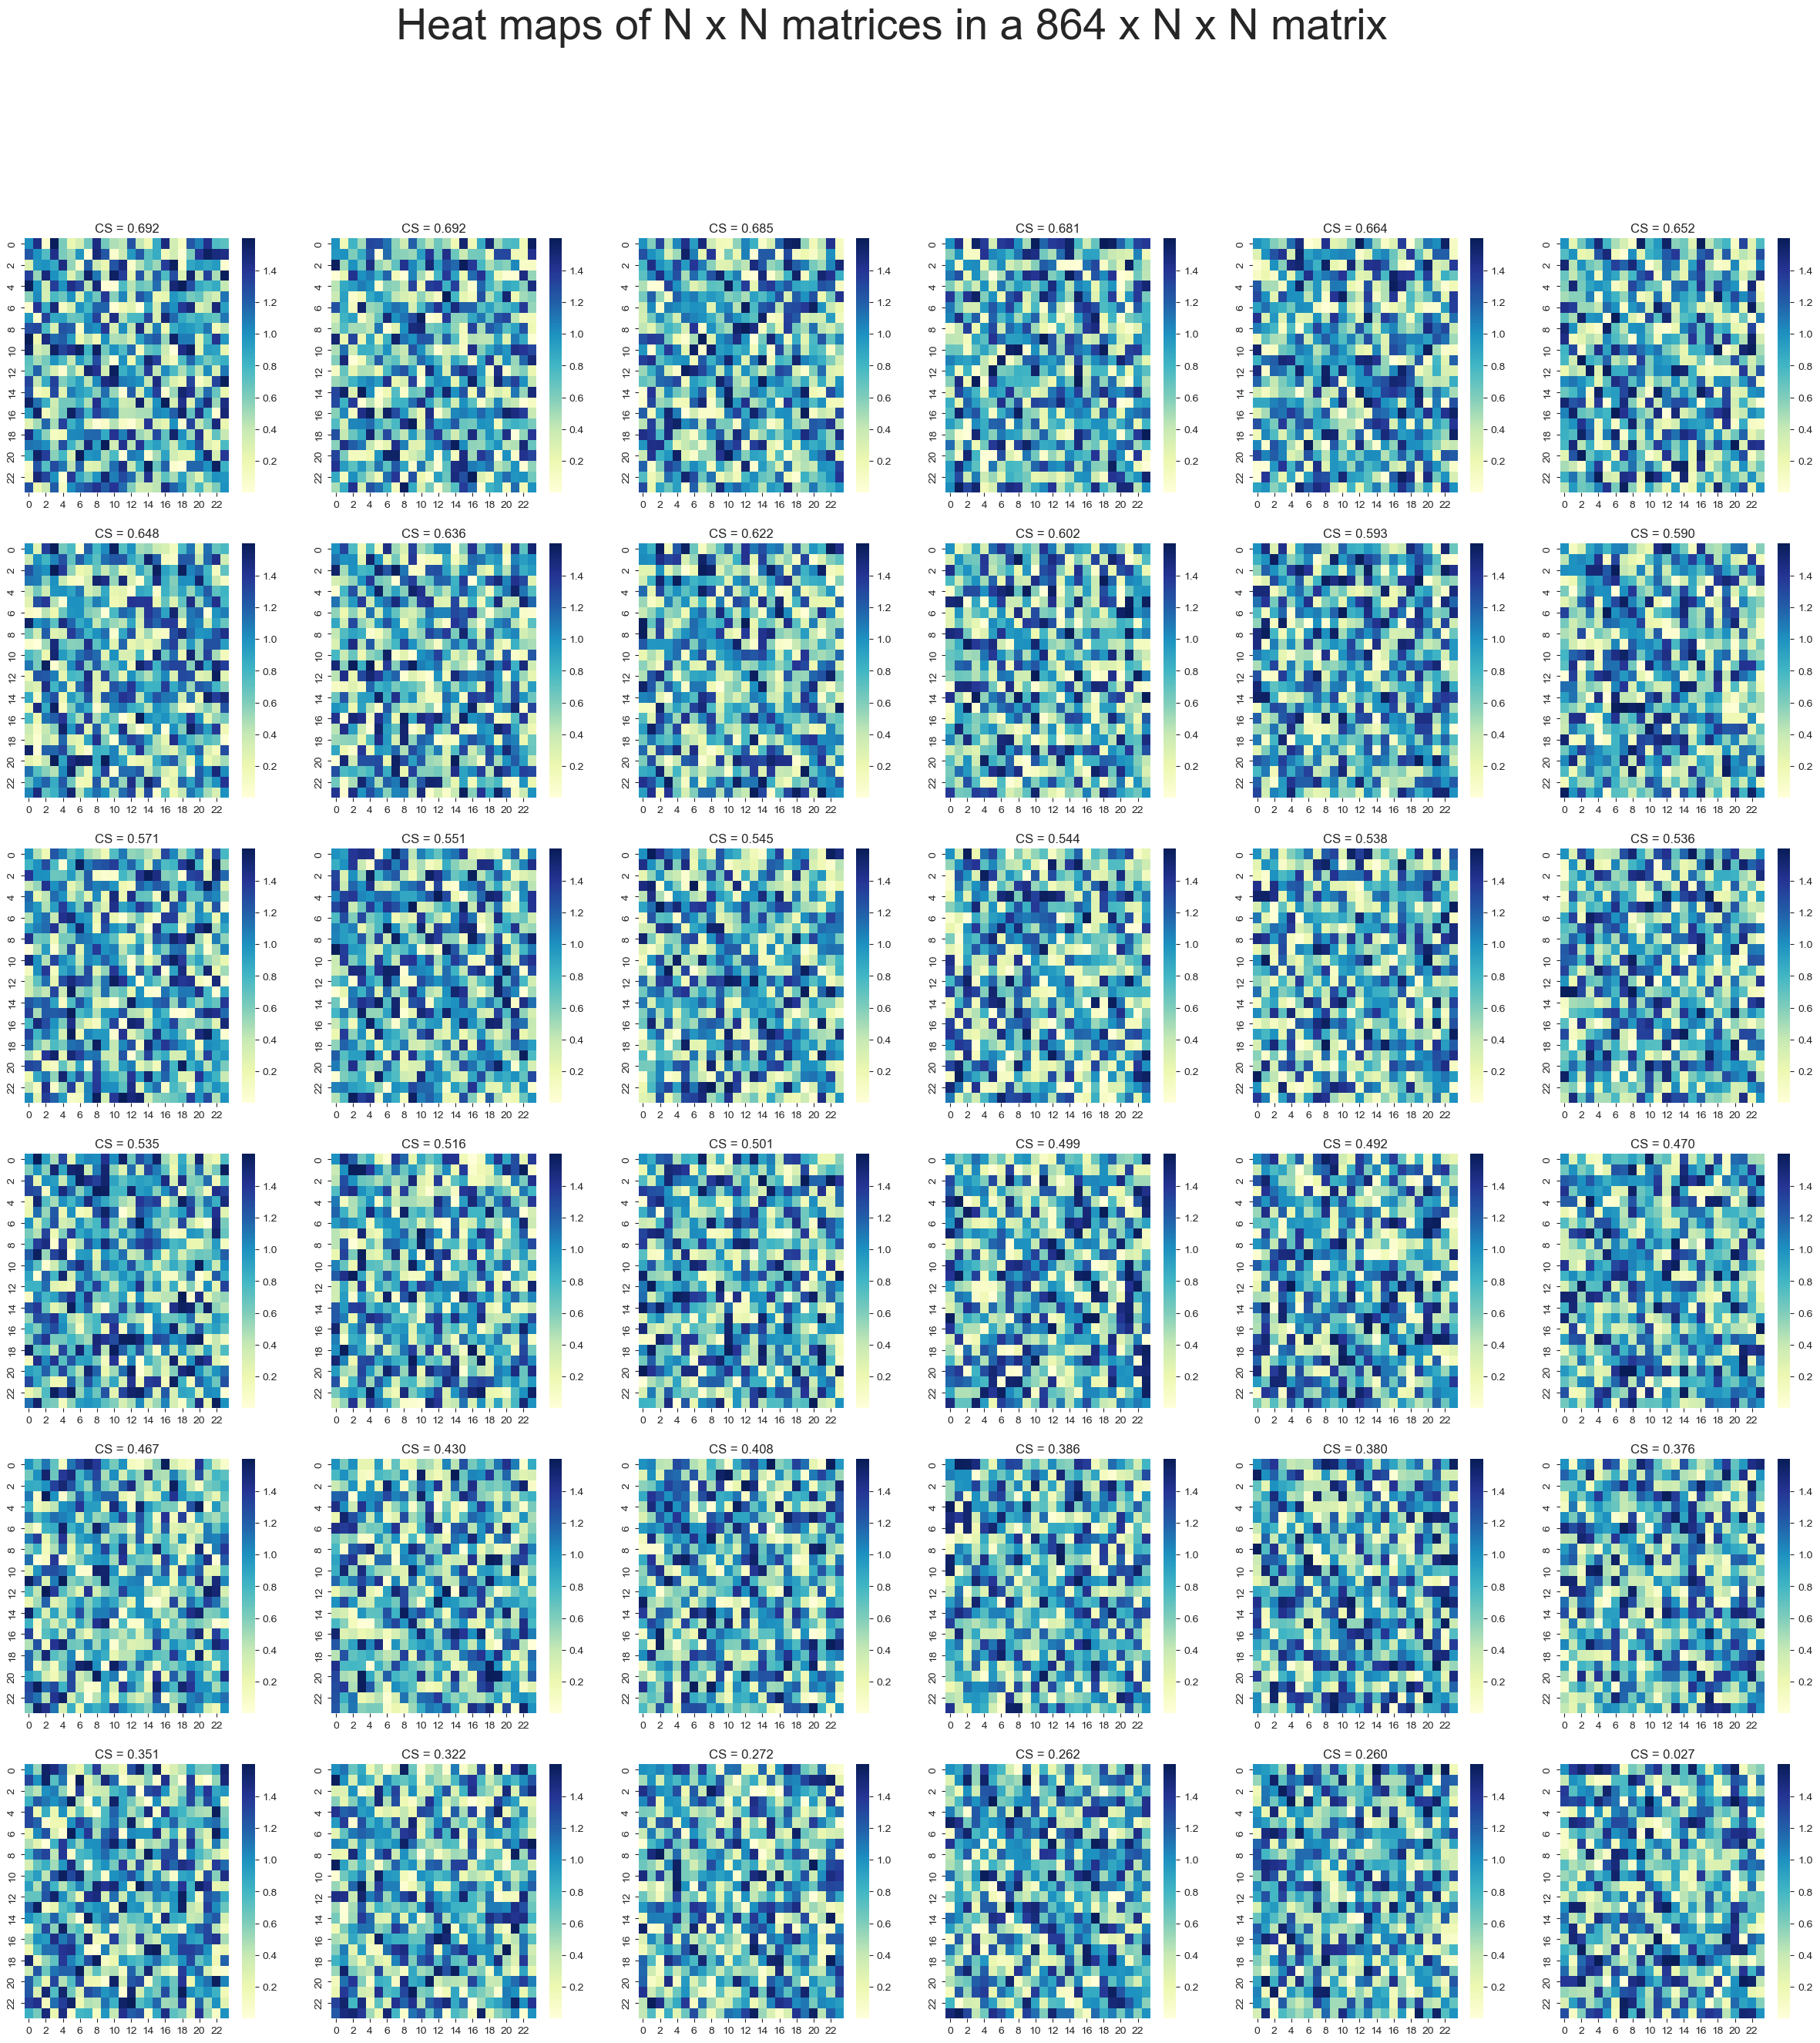

In [205]:

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(30, 30))

I_min=np.min(I[:])
I_max=np.max(I[:])

# Create a heat map for each N x N matrix in I, and plot it in the corresponding subplot
for i, ax in enumerate(axs.flatten()):
    s_idx=CommunitiesLibrary[sorted_idx[i],:]
    s_idx=np.where(s_idx)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    sns.heatmap(I_c, cmap='YlGnBu', vmin=I_min, vmax=I_max, ax=ax)
    ax.set_title('CS = {}'.format(str(competitive_scores[sorted_idx[i]]))[:10])

# Add a title to the figure
fig.suptitle('Heat maps of N x N matrices in a {} x N x N matrix'.format(I.shape[0]), fontsize=40)

# Display the figure
plt.show()
fig.savefig("Figures/Hiearchy_Analysis_largeNumber_heatmap_interaction_beforeAssembly"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')



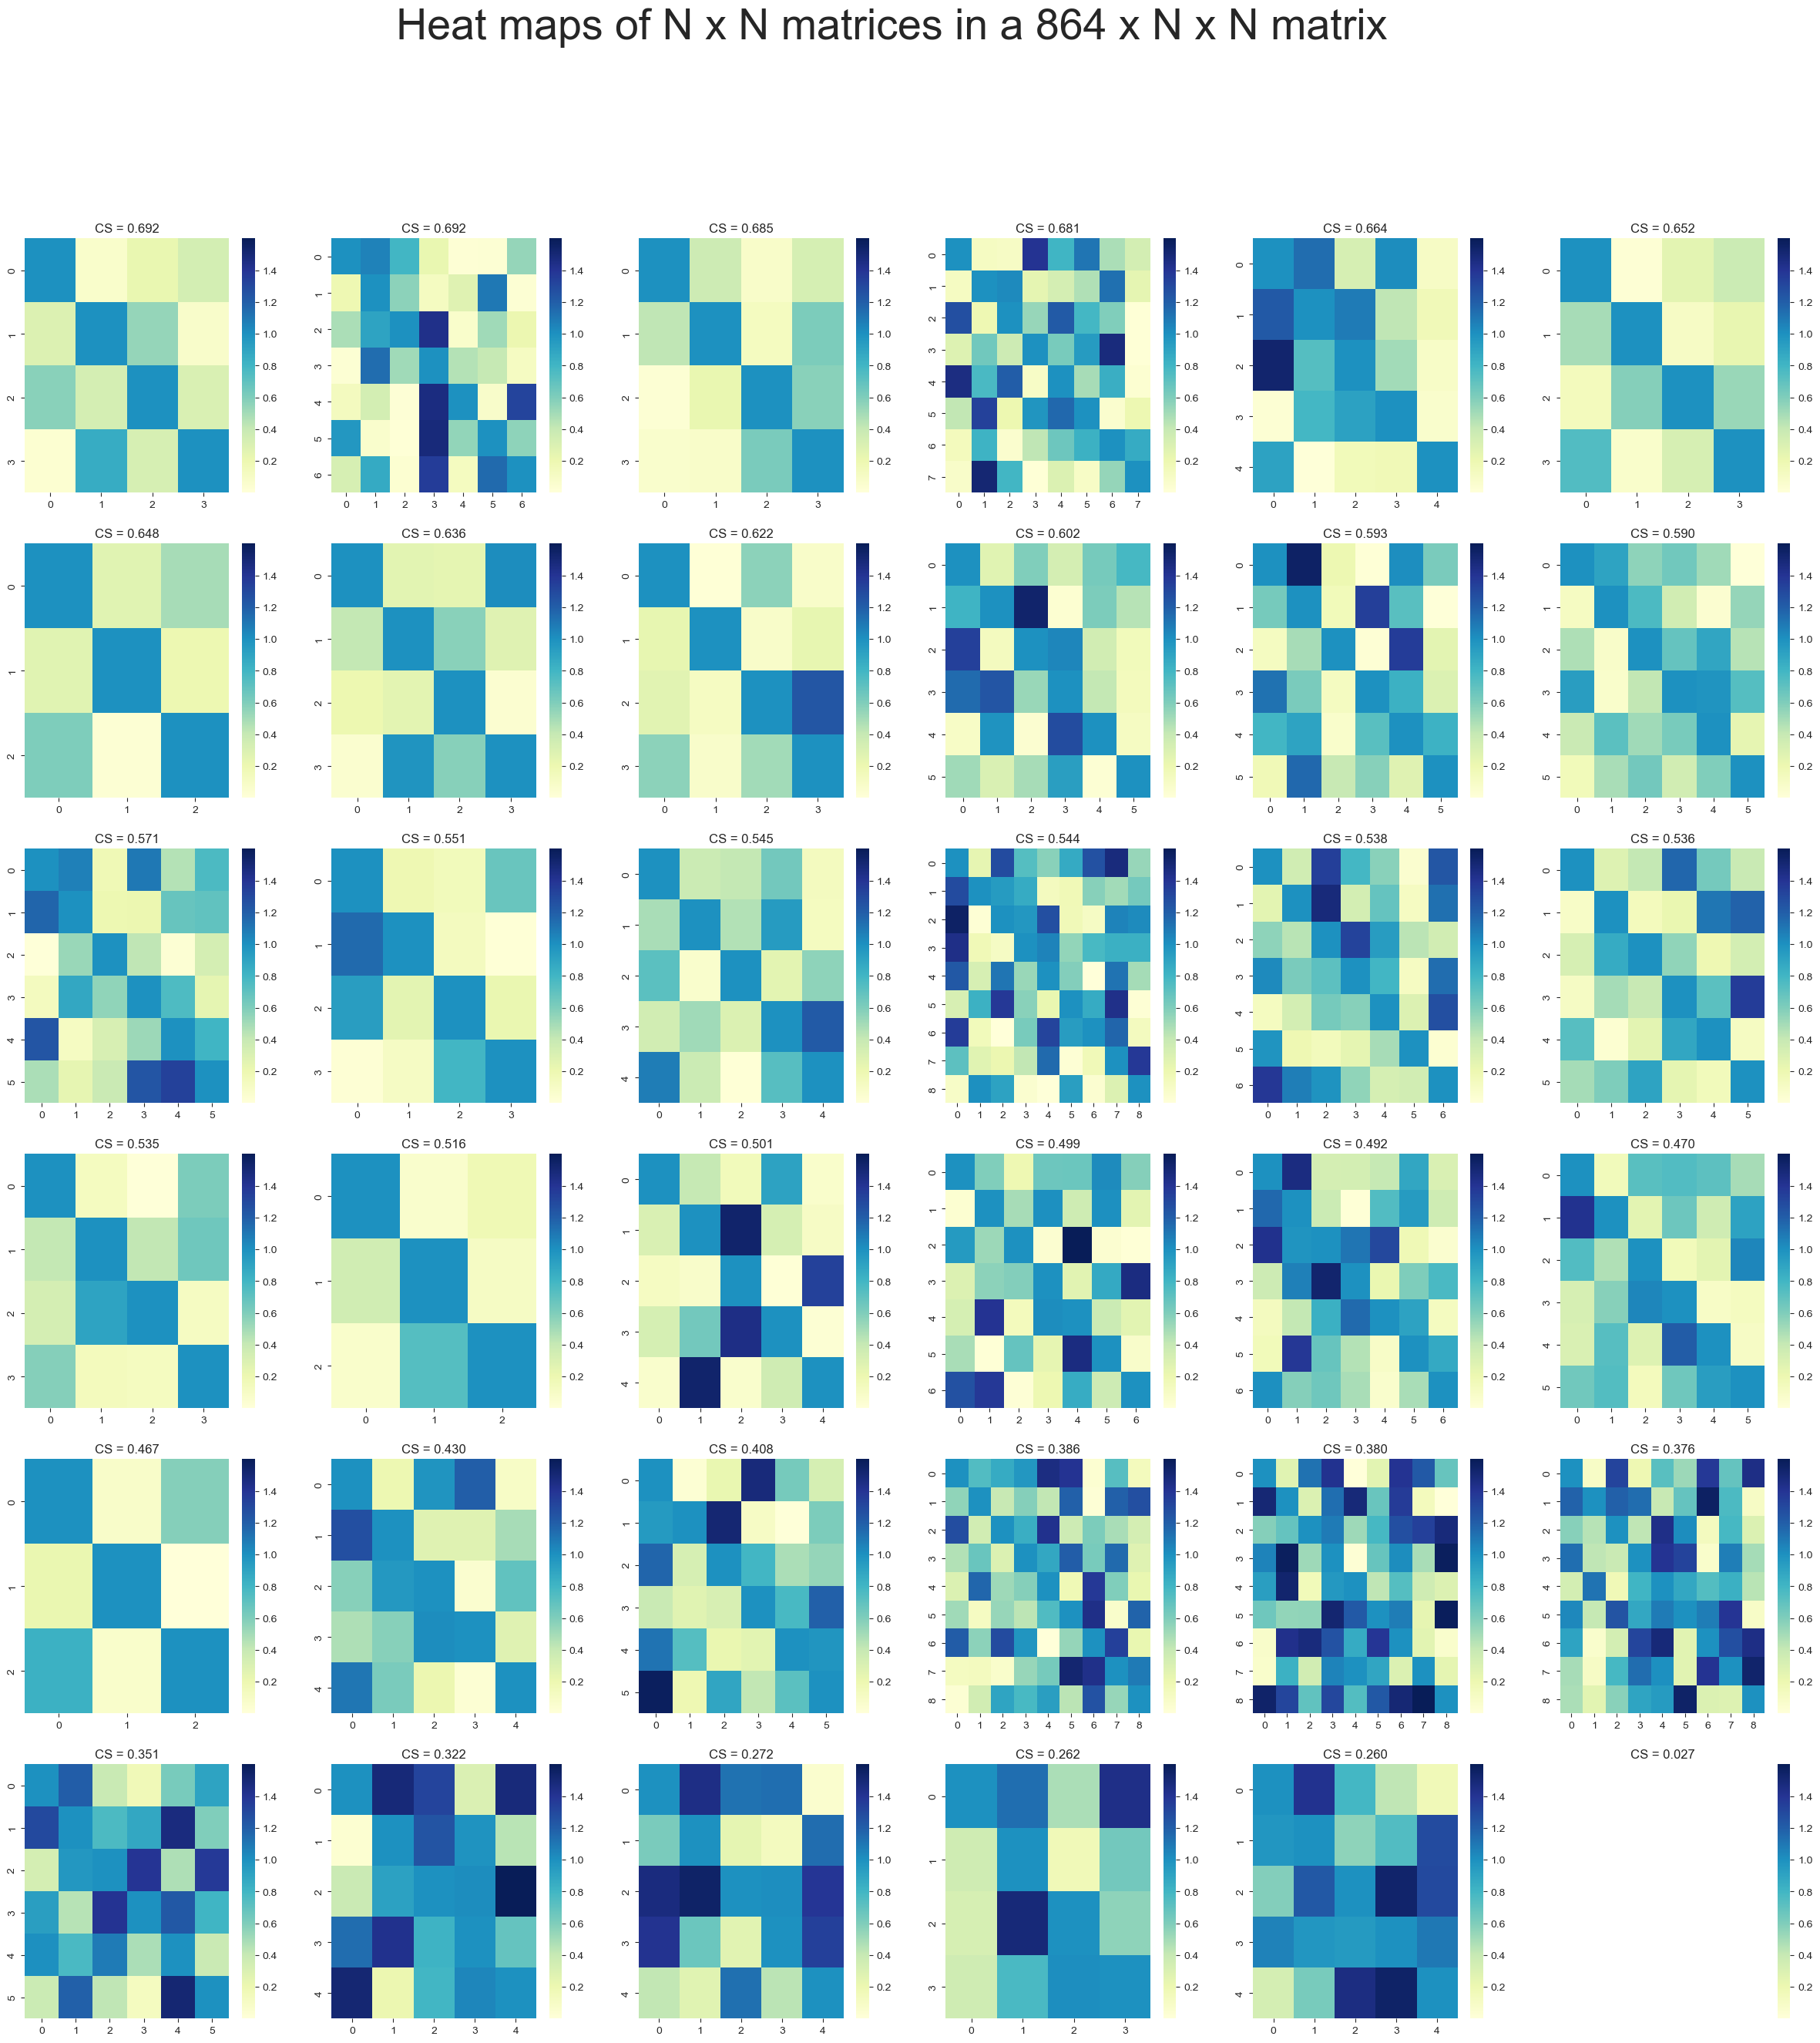

In [206]:

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(30, 30))

I_min=np.min(I[:])
I_max=np.max(I[:])

# Create a heat map for each N x N matrix in I, and plot it in the corresponding subplot
for i, ax in enumerate(axs.flatten()):
    s_idx=np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    
    sns.heatmap(I_c, cmap='YlGnBu', vmin=I_min, vmax=I_max, ax=ax)
    ax.set_title('CS = {}'.format(str(competitive_scores[sorted_idx[i]]))[:10])

# Add a title to the figure
fig.suptitle('Heat maps of N x N matrices in a {} x N x N matrix'.format(I.shape[0]), fontsize=40)

# Display the figure
plt.show()
fig.savefig("Figures/Hiearchy_Analysis_largeNumber_heatmap_interaction_afterAssembly"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')



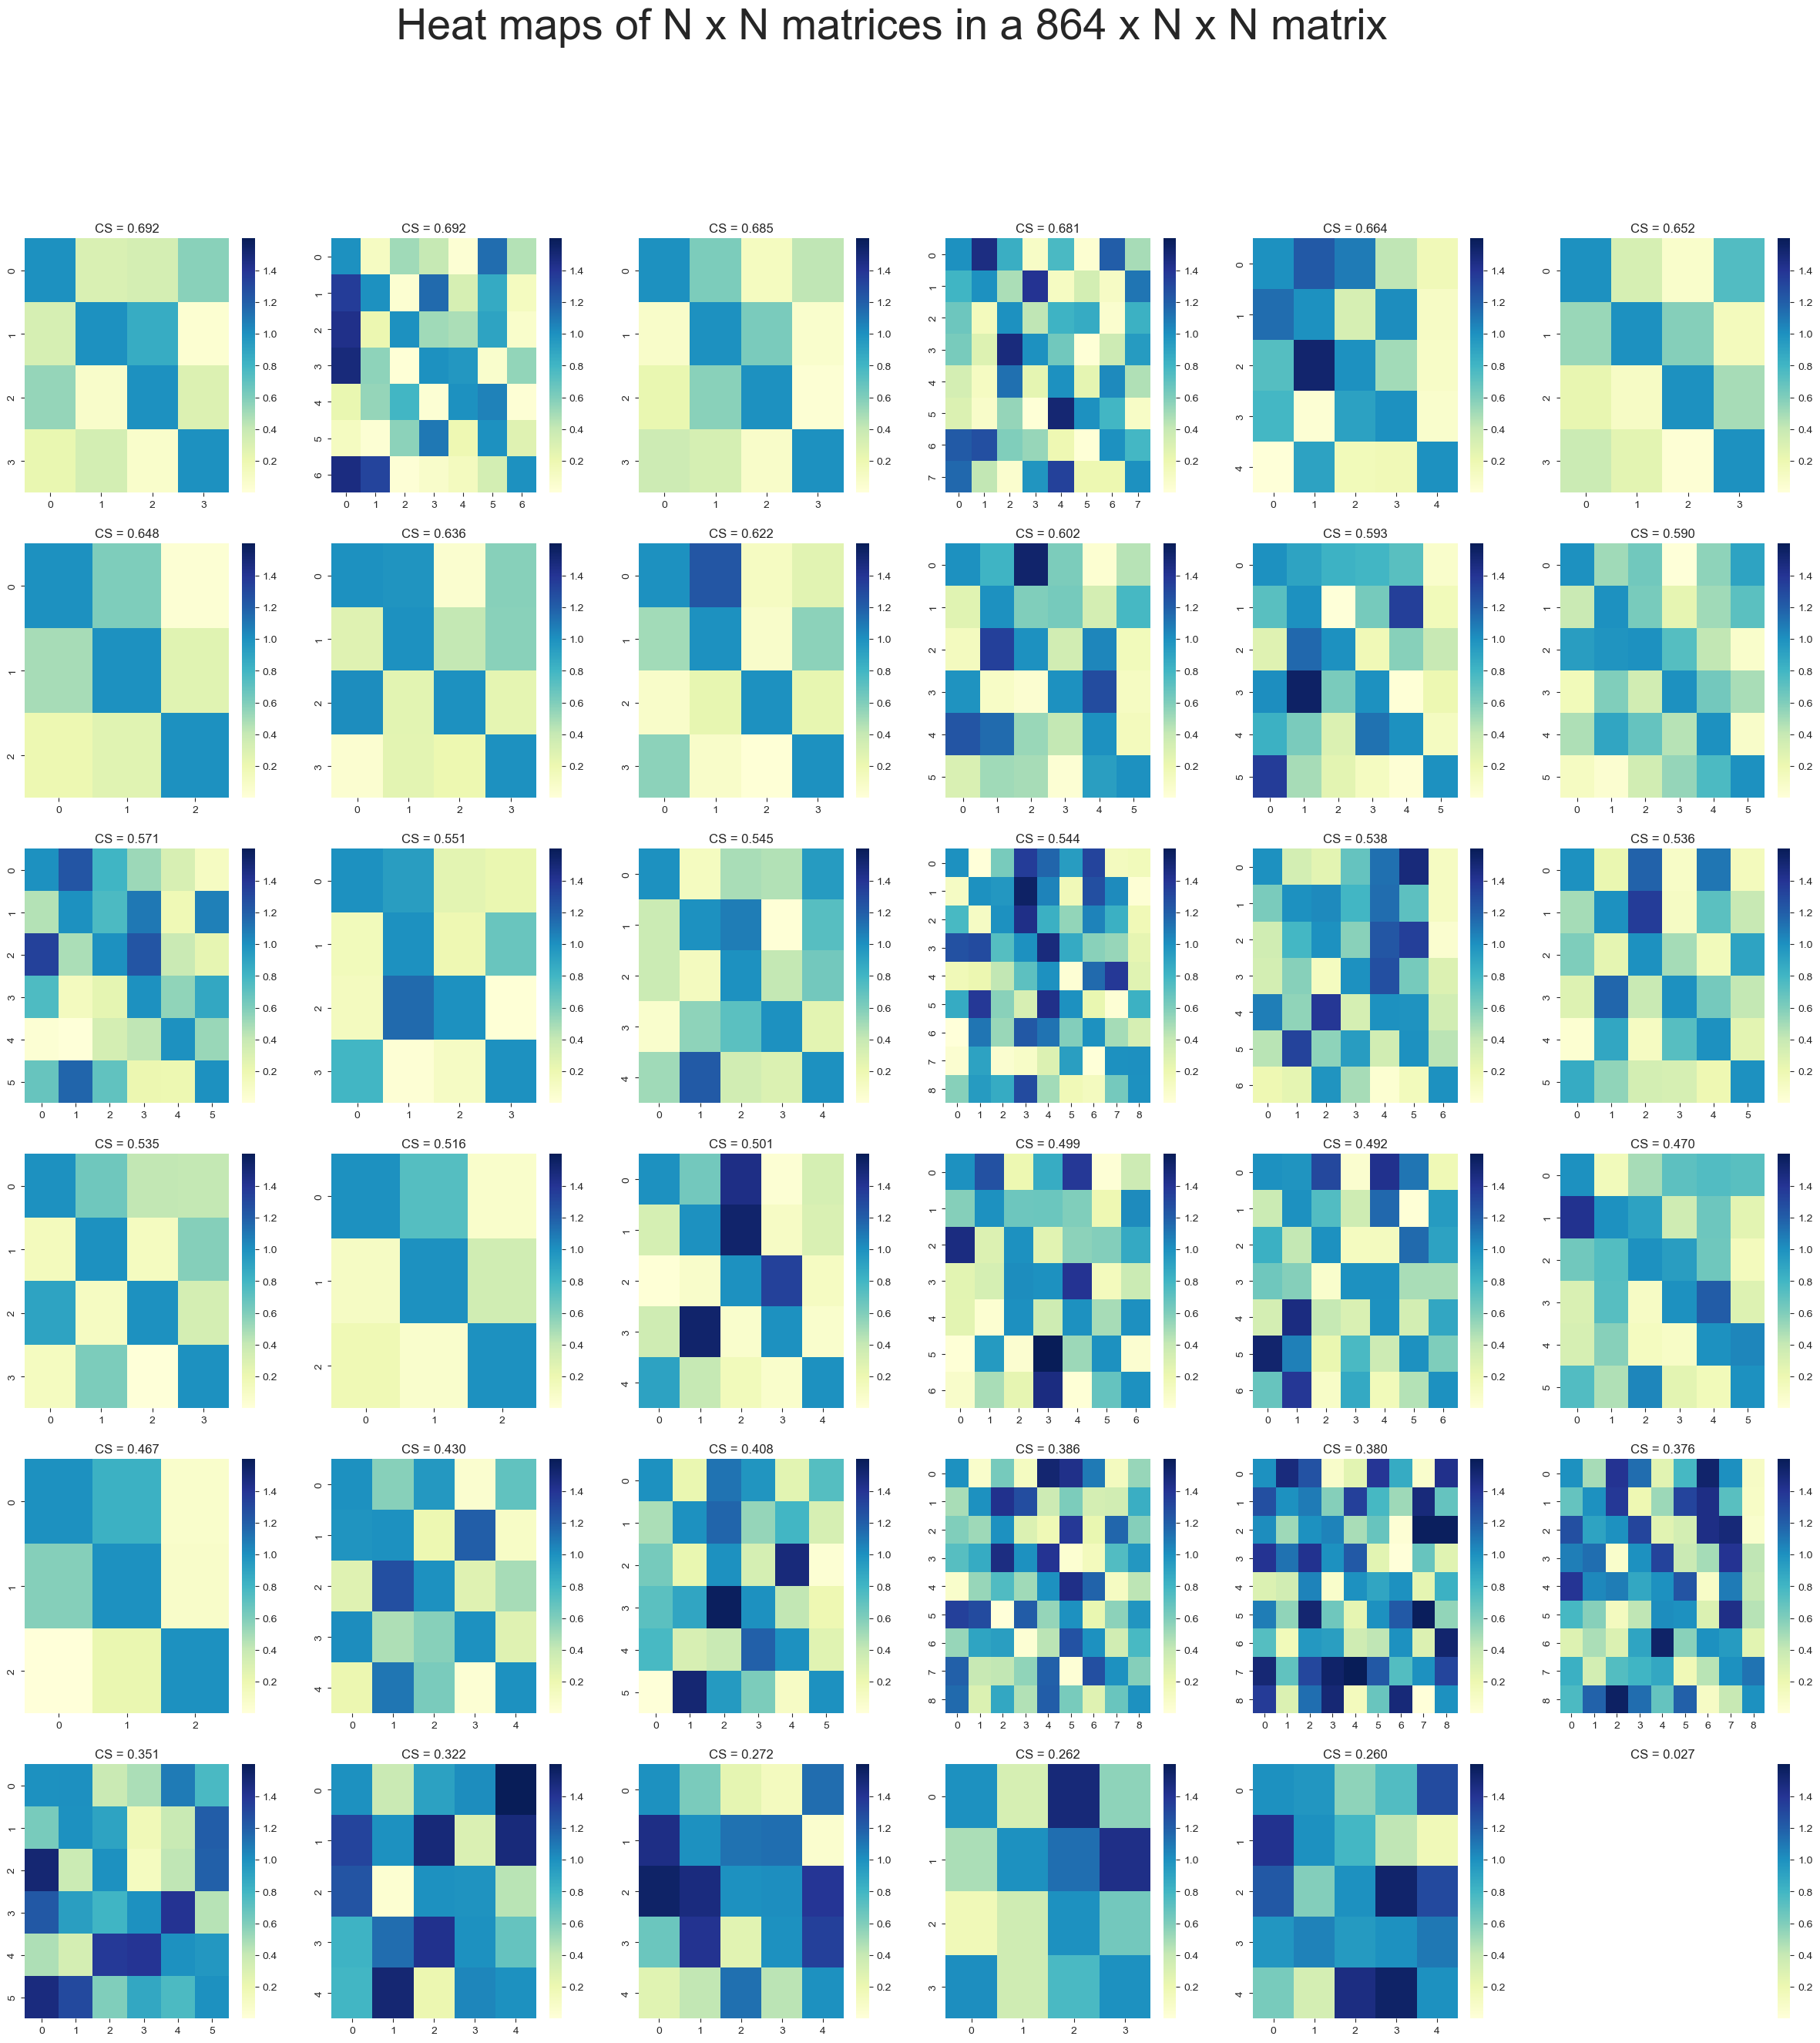

In [207]:

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(30, 30))

I_min=np.min(I[:])
I_max=np.max(I[:])



# Sort rows and columns by competitive score



# Create a heat map for each N x N matrix in I, and plot it in the corresponding subplot
for i, ax in enumerate(axs.flatten()):
    s_idx=np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    A=y_list[sorted_idx[i],:]
    A=A[np.where(A)]
    s_idx = np.argsort(A)
    I_c=I_c[s_idx,:]
    I_c=I_c[:,s_idx]
    
    sns.heatmap(I_c, cmap='YlGnBu', vmin=I_min, vmax=I_max, ax=ax)
    ax.set_title('CS = {}'.format(str(competitive_scores[sorted_idx[i]]))[:10])

# Add a title to the figure
fig.suptitle('Heat maps of N x N matrices in a {} x N x N matrix'.format(I.shape[0]), fontsize=40)

# Display the figure
plt.show()
fig.savefig("Figures/Hiearchy_Analysis_largeNumber_heatmap_interaction_beforeAssembly_sortbyY"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')



array([[0.11582417, 0.15311895, 0.69925041, 0.03180646],
       [0.09601042, 0.43803171, 0.42528856, 0.04066931],
       [0.09932719, 0.09289239, 0.59109347, 0.21668695],
       [0.08749525, 0.02008478, 0.0255862 , 0.86683377]])

([0.4015293042769402,
  0.7437396425194288,
  0.590604700379905,
  0.6795233921442575,
  0.378893920621669,
  0.45237544103097327,
  0.5788221860160353,
  0.5794026905277601,
  0.28810027026464724,
  0.5297849463537143,
  0.6598888302534744,
  0.639964777166411,
  0.5731412418568719,
  0.5003304436164231,
  0.5565902268491517,
  0.5903816200743801,
  0.5654119401397228,
  0.44560024926993896,
  0.41652856321815934,
  0.30994780001733074,
  0.47281274373751603,
  0.3737949397335252,
  0.42346853884855806,
  0.5277803227665461,
  0.4836610189171371,
  0.2911296871695803,
  0.5904903320298083,
  0.6213946043956524,
  0.4903929326536536,
  0.316097191702768,
  0.5549406433447626,
  0.24895360631742428,
  0.5448652842172389,
  0.4012096614592304,
  0.5111345547498248,
  0.6673117513862287],
 array([ 1,  3, 35, 10, 11, 27,  2, 26, 15,  7,  6, 12, 16, 14, 30, 32,  9,
        23, 34, 13, 28, 24, 20,  5, 17, 22, 18,  0, 33,  4, 21, 29, 19, 25,
         8, 31]))

In [151]:
y_list[sorted_idx[i],np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()]

array([0.59110161, 0.11581091, 0.86684337, 0.43803655])

In [153]:
    A=y_list[sorted_idx[i],:]
    A=A[np.where(A)]
    A

array([0.59110161, 0.11581091, 0.86684337, 0.43803655])